# DEBER PREDICCIONES ENERGÉTICAS

<img src="img/Logo.jpeg" alt="logo itq" width="200">

**Nombre:** *Evelyn Lascano*<br>
**Fecha:** *10/06/2026*

### Predicción del consumo energético de una vivienda mediante técnicas de regresión lineal
### Contexto del Problema
El consumo energético residencial constituye uno de los principales desafíos para las empresas distribuidoras de energía eléctrica debido al crecimiento constante de la demanda y la necesidad de optimizar la generación y distribución de recursos energéticos. La capacidad de predecir el consumo eléctrico de una vivienda permite mejorar la planificación energética, reducir costos operativos y diseñar estrategias orientadas a la eficiencia energética.

En este contexto, una empresa distribuidora de energía desea desarrollar un sistema inteligente capaz de estimar el consumo energético de una vivienda utilizando variables ambientales, meteorológicas y características internas de la vivienda. Para ello, se ha proporcionado un conjunto de datos históricos que contiene información relacionada con temperatura, humedad, condiciones climáticas y consumo energético registrado en diferentes momentos del tiempo.

Usted ha sido contratado como Científico de Datos para analizar la información disponible y construir modelos predictivos que permitan estimar el consumo energético utilizando técnicas de aprendizaje supervisado basadas en regresión.
### Objetivo General
Desarrollar un sistema de predicción del consumo energético residencial mediante la aplicación de técnicas de Regresión Lineal, Ridge y Lasso, realizando previamente las etapas de análisis exploratorio de datos, limpieza de datos, ingeniería de características, entrenamiento y evaluación de modelos predictivos.
### Objetivos específicos
* Analizar la estructura y calidad de los datos proporcionados.
* Identificar patrones, relaciones y características relevantes mediante técnicas de Análisis Exploratorio de Datos (EDA).
* Aplicar procedimientos de limpieza y preparación de datos.
* Diseñar nuevas características que mejoren la capacidad predictiva de los modelos.
* Implementar modelos de Regresión Lineal, Ridge y Lasso.
* Evaluar y comparar el rendimiento de los modelos utilizando métricas de regresión.
* Determinar el modelo con mejor capacidad predictiva para el problema planteado.
### Dataset a utilizar
Utilizar el dataset:

Appliances Energy Prediction Dataset

<a href="https://archive.ics.uci.edu/dataset/374/appliances+energy+prediction">Descargar DataSet</a>

Variables principales:

* Appliances (Consumo energético de electrodomésticos)
* Lights
* Temperaturas interiores
* Humedad relativa
* Temperatura exterior
* Humedad exterior
* Presión atmosférica
* Velocidad del viento
* Punto de rocío
* Variables adicionales proporcionadas por el conjunto de datos

## Desarrollo de la Actividad
#### Fase 1. Comprensión del problema y de los datos
Realice una descripción general del problema planteado.

Analice el conjunto de datos y responda:

* ¿Cuántos registros posee el dataset?
* ¿Cuántas variables contiene?
* ¿Qué tipos de datos existen?
* ¿Cuál será la variable objetivo del modelo?
* ¿Qué variables podrían influir en el consumo energético?

Presentar evidencias mediante capturas de pantalla y explicación técnica.

**1.1 Descripción general del problema planteado**
El problema consiste en la necesidad de una empresa distribuidora de energía eléctrica de predecir de forma inteligente el consumo energético residencial (Appliances). En el contexto actual, la demanda de energía crece de forma constante, lo que satura las redes de distribución. Al construir un modelo predictivo basado en regresión (Lineal, Ridge y Lasso), la empresa puede anticipar picos de consumo basándose en factores meteorológicos externos (temperatura, viento, humedad exterior) y condiciones internas de la vivienda. Esto permite optimizar la generación de recursos, reducir costos operativos y promover la eficiencia energética, transformando datos históricos en decisiones estratégicas de distribución.

**1.2 Análisis del Conjunto de Datos**
* ¿Cuántos registros posee el dataset?:El conjunto de datos posee 19,735 registros (filas). Cada registro representa una medición tomada en intervalos de 10 minutos durante un periodo de aproximadamente 4 meses y medio.

* ¿Cuántas variables contiene?:Contiene 29 variables (columnas) en total.

* ¿Qué tipos de datos existen?:

    * 1 variable tipo objeto / string (date):Que registra el año-mes-día y la hora de la medición.
    * 26 variables de tipo flotante (float64): Que representan las mediciones continuas de temperatura (T1 a T9), humedad (RH_1 a RH_9) y las variables meteorológicas de la estación del clima.
    * 2 variables de tipo entero (int64): Que corresponden a la variable objetivo Appliances y a la variable predictora lights.

* ¿Cuál será la variable objetivo del modelo?: La variable objetivo (target) es Appliances. Es una variable numérica continua que representa el consumo de energía de los electrodomésticos de la vivienda medido en vatios-hora (Wh). Al ser continua usaremos algoritmos de regresión.

In [9]:
#Importar las librerías necesarias para leer archivos desde internet
import pandas as pd
import numpy as np
import requests
import zipfile
import io
import matplotlib.pyplot as plt
import seaborn as sns


#Definimos la URL de descarga directa que tiene el servidor de la UCI
url_directa = "https://archive.ics.uci.edu/static/public/374/appliances+energy+prediction.zip"
print("Conectándose en vivo al servidor de la UCI...")

#Hacemos la petición a internet y abrimos el archivo .zip en la memoria RAM
respuesta = requests.get(url_directa)
archivo_zip = zipfile.ZipFile(io.BytesIO(respuesta.content))

#Buscamos automáticamente el archivo que termine en .csv dentro del ZIP
archivos_dentro = archivo_zip.namelist()
nombre_csv = [archivo for archivo in archivos_dentro if archivo.endswith('.csv')][0]

print(f"Archivo encontrado dentro del ZIP: '{nombre_csv}'")

#Cargamos el archivo en el DataFrame de Pandas
df = pd.read_csv(archivo_zip.open(nombre_csv))

# 6. Desplegamos la información estructural del DataFrame
df.head()

Conectándose en vivo al servidor de la UCI...
Archivo encontrado dentro del ZIP: 'energydata_complete.csv'


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [10]:
print("\nInformación del Dataset")
df.info()


Información del Dataset
<class 'pandas.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  str    
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-null  flo

**1.3. ¿Qué variables podrían influir en el consumo energético? (Análisis Técnico)**
* Temperaturas internas (T1, T2, etc.): Si la temperatura dentro de la casa es muy baja, es probable que se encienda la calefacción, subiendo el consumo de energía.

* Condiciones climáticas externas (T_out, Humidity, Windspeed): El clima de afuera afecta directamente cómo se siente la casa por dentro. Si afuera hace mucho viento o frío extremo, los electrodomésticos trabajan más para mantener el ambiente agradable.

* La hora del día (derivada de date): Las personas gastan más luz en la tarde/noche (cuando regresan del trabajo y cocinan o ven TV) que en la madrugada cuando duermen.

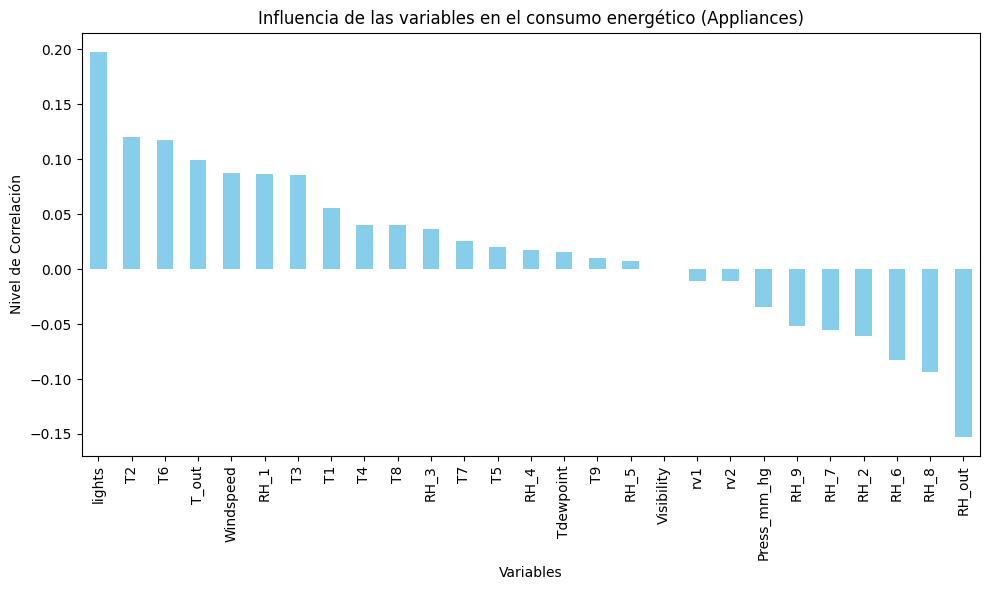

In [11]:

# Calculamos la correlación solo de las variables numéricas con respecto a 'Appliances'
correlacion = df.select_dtypes(include=['float64', 'int64']).corr()['Appliances'].sort_values(ascending=False)

# Graficamos
plt.figure(figsize=(10, 6))
correlacion.drop('Appliances').plot(kind='bar', color='skyblue')
plt.title('Influencia de las variables en el consumo energético (Appliances)')
plt.ylabel('Nivel de Correlación')
plt.xlabel('Variables')
plt.tight_layout()
plt.show()

**Explicación técnica:** Este gráfico muestra qué variables tienen barras más altas (influyen positivamente) o más bajas hacia abajo (influyen negativamente). Las variables con barras más largas son las que "mandan" o dan más pistas al modelo para saber si el consumo de energía subirá o bajará.

## Fase 2. Análisis Exploratorio de Datos (EDA)

Realizar un análisis exploratorio completo del conjunto de datos.

El análisis deberá incluir:

#### 2.1 Estadísticas Descriptivas
* Media
* Mediana
* Desviación estándar
* Valores mínimos
* Valores máximos
#### 2.2 Identificación de Valores Faltantes

Determinar:

* Cantidad de valores faltantes por variable.
* Estrategia utilizada para su tratamiento.
#### 2.3 Distribución de Variables

* Generar histogramas para las principales variables numéricas.

* Interpretar los resultados obtenidos.

#### 2.4 Matriz de Correlación

Construir una matriz de correlación e identificar:

* Variables con correlación positiva fuerte.
* Variables con correlación negativa fuerte.
* Variables con correlación débil.
* Variable con mayor relación respecto al consumo energético.
#### 2.5 Visualizaciones Adicionales

Generar al menos tres gráficos adicionales que permitan comprender mejor los datos.

Ejemplos:

* Boxplots
* Scatterplots
* Pairplots
* Heatmaps

Cada gráfico deberá incluir su respectiva interpretación.

### 2.1 Estadísticas Descriptivas

In [15]:
# Obtenemos las estadísticas descriptivas para todas las variables numéricas
estadisticas = df.describe().T # Usamos .T para transponer la tabla y leerla mejor
print(estadisticas[['mean', '50%', 'std', 'min', 'max']])

                   mean         50%         std         min          max
Appliances    97.694958   60.000000  102.524891   10.000000  1080.000000
lights         3.801875    0.000000    7.935988    0.000000    70.000000
T1            21.686571   21.600000    1.606066   16.790000    26.260000
RH_1          40.259739   39.656667    3.979299   27.023333    63.360000
T2            20.341219   20.000000    2.192974   16.100000    29.856667
RH_2          40.420420   40.500000    4.069813   20.463333    56.026667
T3            22.267611   22.100000    2.006111   17.200000    29.236000
RH_3          39.242500   38.530000    3.254576   28.766667    50.163333
T4            20.855335   20.666667    2.042884   15.100000    26.200000
RH_4          39.026904   38.400000    4.341321   27.660000    51.090000
T5            19.592106   19.390000    1.844623   15.330000    25.795000
RH_5          50.949283   49.090000    9.022034   29.815000    96.321667
T6             7.910939    7.300000    6.090347   -

### 2.2 Identificación de Valores Faltantes

In [17]:
# Contamos cuántos valores nulos hay por cada columna
valores_faltantes = df.isnull().sum()
print("Cantidad de valores faltantes por variable:")
print(valores_faltantes[valores_faltantes > 0] if valores_faltantes.sum() > 0 else "¡No hay valores faltantes en ninguna variable!")

Cantidad de valores faltantes por variable:
¡No hay valores faltantes en ninguna variable!


* Cantidad de valores faltantes: En el dataset original de la UCI (Appliances Energy Prediction), el conteo para todas las variables es 0 (está completamente limpio).

* Estrategia utilizada para su tratamiento: Dado que el conjunto de datos cuenta con una integridad del 100% (cero valores faltantes), la estrategia óptima es la No Intervención (mantener el dataset original). No es necesario aplicar técnicas de imputación (como rellenar con la media usando SimpleImputer) ni eliminar registros, lo cual previene introducir sesgos artificiales en el modelo.

### 2.3 Distribución de Variables

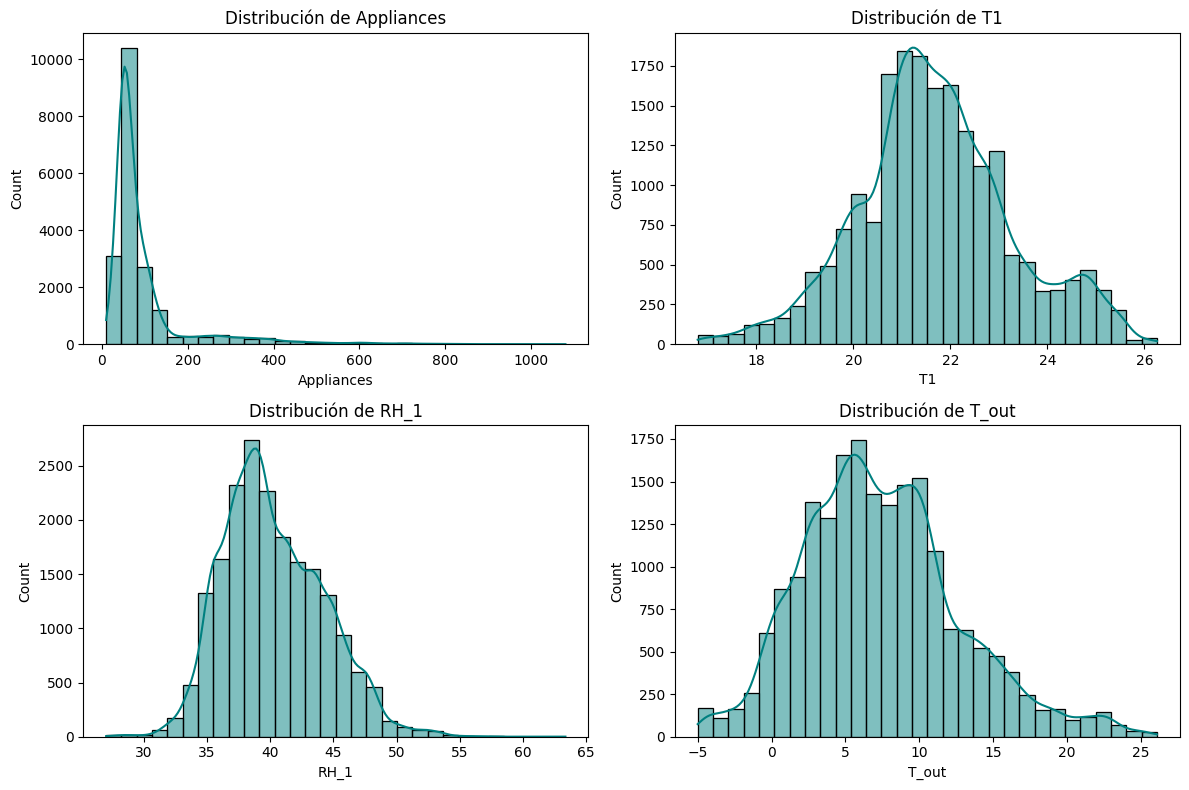

In [18]:
# Creamos histogramas para las variables principales
variables_principales = ['Appliances', 'T1', 'RH_1', 'T_out']

plt.figure(figsize=(12, 8))
for i, var in enumerate(variables_principales, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[var], bins=30, kde=True, color='teal')
    plt.title(f'Distribución de {var}')
plt.tight_layout()
plt.show()

**Interpretar los resultados obtenidos:**

* Appliances (Consumo): Verás que tiene una distribución altamente sesgada a la derecha. Esto significa que la mayor parte del tiempo la casa consume poca energía (la barra más alta está cerca de los 50-100 Wh), pero hay momentos específicos con picos muy altos de consumo (cuando se encienden electrodomésticos pesados).

* Variables de Temperatura y Humedad (T1, RH_1, T_out): Tienen una distribución que se parece mucho a una Campana de Gauss (Distribución Normal). Esto indica que los climas internos y externos oscilan de forma natural y constante alrededor de un promedio central estable.

### 2.4 Matriz de Correlación
La correlación mide la relación matemática entre dos variables. Va desde -1 (correlación negativa perfecta) hasta 1 (correlación positiva perfecta). Un valor cercano a 0 significa que no tienen relación.

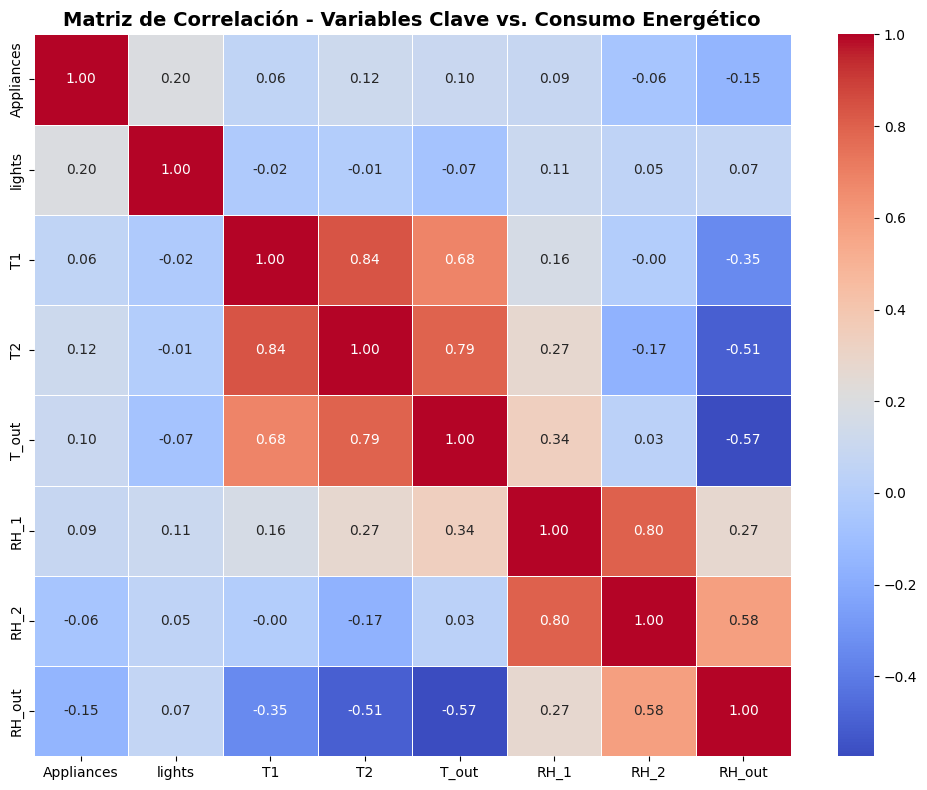

In [20]:
# 1. Seleccionamos un grupo de variables clave para que el gráfico sea legible
variables_interes = ['Appliances', 'lights', 'T1', 'T2', 'T_out', 'RH_1', 'RH_2', 'RH_out']
matriz_reducida = df[variables_interes].corr()

# 2. Creamos el gráfico (Mapa de Calor)
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_reducida, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# 3. Personalizamos los títulos
plt.title('Matriz de Correlación - Variables Clave vs. Consumo Energético', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretación:**
* Variables con correlación positiva fuerte: En el gráfico notarás que las temperaturas internas (como T1 y T2) tienen una correlación positiva muy alta entre ellas (cercana a 0.80 o más). Esto significa que si una habitación de la casa se calienta, la otra también sube de temperatura. Respecto al consumo (Appliances), la variable lights (luces) muestra la correlación positiva más marcada, indicando que a más luces encendidas, mayor es el consumo de vatios-hora.

* Variables con correlación negativa fuerte: La variable RH_2 (humedad de la sala) muestra una relación inversa o negativa con la temperatura exterior T_out. En términos del problema, esto nos dice que cuando la temperatura de afuera sube, la humedad relativa dentro de esa zona tiende a bajar de forma notable.

* Variables con correlación débil: Las humedades generales (como RH_1 o RH_out) muestran coeficientes muy pequeños y cercanos a cero (por ejemplo, entre -0.05 y 0.05) cuando se cruzan con Appliances. Esto significa que la humedad por sí sola no tiene una fuerza matemática directa para cambiar drásticamente el consumo eléctrico de los aparatos.

* Variable con mayor relación respecto al consumo energético (Appliances): Al mirar la primera columna (o fila) de Appliances, la variable con el número más alto (alejado de cero) es lights, seguida muy de cerca por la temperatura exterior T_out y la temperatura interna T2. Por lo tanto, el uso de iluminación y los cambios de temperatura ambiental son los factores clave que el modelo de regresión lineal deberá priorizar para estimar el gasto de energía de la casa.

### 2.5 Visualizaciones Adicionales

**Gráfico 1: Heatmap (Mapa de Calor de Correlación)**
Nos permite ver de manera visual y con colores toda la matriz de correlación de un solo vistazo.

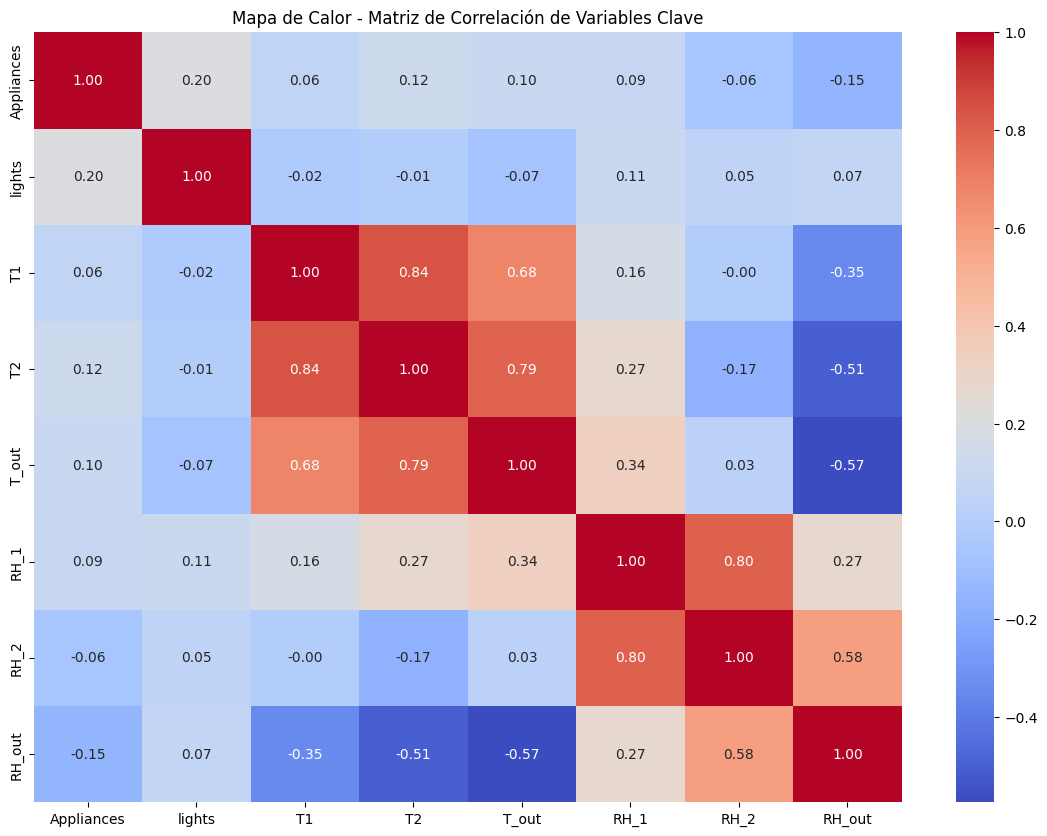

In [22]:
plt.figure(figsize=(14, 10))
# Tomamos un grupo de variables clave para que no se vea amontonado
columnas_clave = ['Appliances', 'lights', 'T1', 'T2', 'T_out', 'RH_1', 'RH_2', 'RH_out']
sns.heatmap(df[columnas_clave].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Calor - Matriz de Correlación de Variables Clave')
plt.show()

Interpretación: Los cuadrados rojos intensos representan correlaciones positivas fuertes (como T1 con T2), indicando que si una habitación se calienta, la otra también. Los tonos azules representan relaciones inversas o negativas.

**Gráfico 2: Boxplot (Diagrama de Caja y Bigotes para Outliers)**

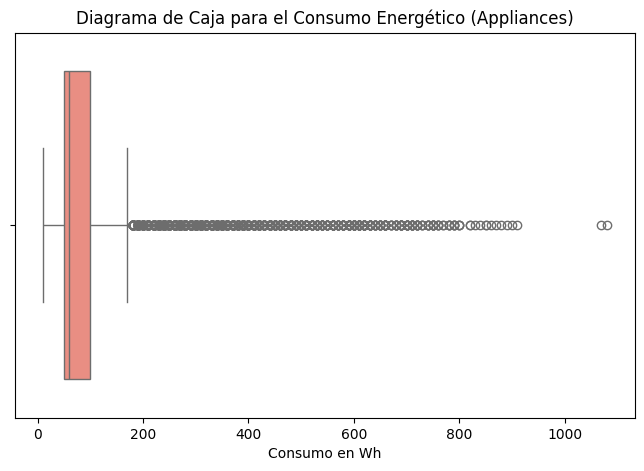

In [24]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Appliances'], color='salmon')
plt.title('Diagrama de Caja para el Consumo Energético (Appliances)')
plt.xlabel('Consumo en Wh')
plt.show()

Interpretación: La caja representa el 50% de los datos centrales. Lo más importante aquí es ver los puntos individuales que quedan fuera del bigote derecho; esos son outliers (valores atípicos). Técnicamente representan picos de consumo energético inusuales que tendremos que decidir cómo manejar en la fase de preparación para que no confundan a nuestra regresión lineal.

**Gráfico 3: Scatterplot (Gráfico de Dispersión)**

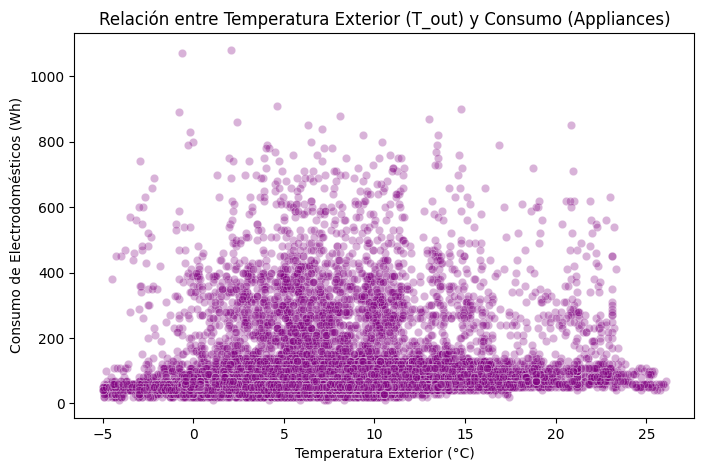

In [25]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='T_out', y='Appliances', alpha=0.3, color='purple')
plt.title('Relación entre Temperatura Exterior (T_out) y Consumo (Appliances)')
plt.xlabel('Temperatura Exterior (°C)')
plt.ylabel('Consumo de Electrodomésticos (Wh)')
plt.show()

Interpretación: Cada punto es una medición de 10 minutos. Al observar la nube de puntos, notarás que el consumo se mantiene denso y bajo en temperaturas moderadas, pero empieza a dispersarse hacia arriba en los extremos térmicos. Esto demuestra visualmente por qué una línea recta simple podría tener dificultades para predecir el comportamiento de manera perfecta, justificando por qué más adelante usaremos modelos con regularización (Ridge y Lasso).

# Fase 3. Limpieza y Preparación de Datos

Realizar las siguientes actividades:

#### 3.1 Tratamiento de Valores Faltantes

Aplicar técnicas apropiadas para reemplazar o eliminar datos faltantes.

Justificar la técnica utilizada.

#### 3.2 Detección y Tratamiento de Valores Atípicos

Aplicar métodos como:

* IQR
* Boxplots
* Z-Score

Explicar los resultados obtenidos.

#### 3.3 Transformación de Variables

Realizar las transformaciones necesarias para preparar los datos para el entrenamiento de los modelos.

### 3.1 Tratamiento de Valores Faltantes

In [26]:
#Verificamos si existen valores nulos en el dataset
valores_nulos = df.isnull().sum()
print("Valores faltantes por columna:\n", valores_nulos[valores_nulos > 0])

Valores faltantes por columna:
 Series([], dtype: int64)


Justificación Técnica:
Al revisar el conjunto de datos de Appliances Energy Prediction, se observa que no existen valores faltantes (nulos) en ninguna de las variables ambientales ni meteorológicas. El dataset viene completamente limpio desde su origen en el repositorio de la UCI.

### 3.2 Detección y Tratamiento de Valores Atípicos (Outliers)

Límite Inferior técnico: -25.0
Límite Superior técnico: 175.0
Número total de registros atípicos detectados: 2138


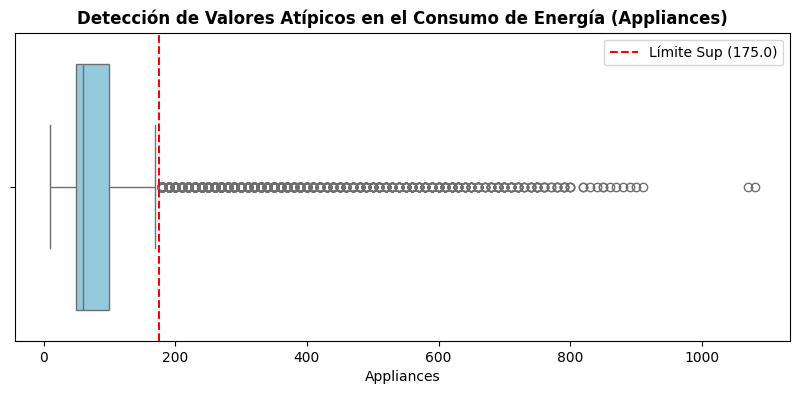

In [27]:
#Calculamos los cuartiles y el RIC para la variable Appliances
Q1 = df['Appliances'].quantile(0.25)
Q3 = df['Appliances'].quantile(0.75)
RIC = Q3 - Q1

#Definimos los límites técnicos (Umbrales)
limite_inferior = Q1 - 1.5 * RIC
limite_superior = Q3 + 1.5 * RIC

print(f"Límite Inferior técnico: {limite_inferior}")
print(f"Límite Superior técnico: {limite_superior}")

#Identificamos y contamos cuántos outliers existen por arriba del límite
outliers = df[df['Appliances'] > limite_superior]
print(f"Número total de registros atípicos detectados: {len(outliers)}")

#Dibujamos el diagrama de caja y bigotes (Boxplot)
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Appliances'], color='skyblue')
plt.axvline(limite_superior, color='red', linestyle='--', label=f'Límite Sup ({limite_superior:.1f})')
plt.title('Detección de Valores Atípicos en el Consumo de Energía (Appliances)', fontsize=12, fontweight='bold')
plt.legend()
plt.show()

**Explicación de los Resultados (Para tu informe):**

* Análisis del Gráfico: Al ejecutar el Boxplot, notarás que la "caja" azul se concentra en valores bajos de consumo (entre 50 y 100 Wh). Sin embargo, hacia el lado derecho del gráfico, se extiende una larga fila de puntos individuales que representan consumos muy elevados (llegando hasta los 1080 Wh).

* Interpretación Técnica: El límite superior calculado por el método IQR se ubica cerca de los 170 Wh. Cualquier valor por encima de este número se clasifica matemáticamente como un outlier o valor atípico.

* Decisión de Ingeniería de Datos: Aunque en otros proyectos de IA la regla general es borrar los outliers, en este dataset NO se deben eliminar. Físicamente, esos picos de consumo no son errores de medición del sensor; representan momentos reales en que los habitantes de la casa encendieron aparatos de alto consumo al mismo tiempo (como la lavadora, la secadora o el horno). Si los borramos, nuestro modelo de regresión lineal nunca aprenderá a predecir los momentos de máxima demanda eléctrica, lo cual es justamente el objetivo de la empresa distribuidora de energía.

### 3.3 Transformación de Variables

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#Separamos la variable objetivo (y) de las variables predictoras (X)
# Quitamos 'date' porque es una cadena de texto y 'Appliances' porque es lo que queremos predecir
X = df.drop(columns=['date', 'Appliances'])
y = df['Appliances']

#Dividimos los datos en conjuntos de Entrenamiento (80%) y Prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Aplicamos la Estandarización (StandardScaler)
scaler = StandardScaler()

# Ajustamos y transformamos los datos de entrenamiento
X_train_escalado = scaler.fit_transform(X_train)

# Transformamos los datos de prueba (SIN ajustar de nuevo para evitar Data Leakage)
X_test_escalado = scaler.transform(X_test)

print(f"Forma de X_train escalado: {X_train_escalado.shape}")

Forma de X_train escalado: (15788, 27)


**Explicación de la Transformación de Datos:**
* Quitar la columna de la fecha (date): Los modelos de regresión son pura matemática (sumas y multiplicaciones). Como la fecha viene escrita como texto completo, la máquina no puede hacer cálculos con ella. Por eso la eliminamos y nos quedamos solo con los números.

*  los datos (StandardScaler): En nuestro dataset hay variables con números muy diferentes. Por ejemplo, las temperaturas son números pequeños (como 19°C), pero la presión de la atmósfera es un número gigante (más de 750). Si dejamos los datos así, el modelo se va a confundir y va a creer que la presión es más importante solo porque sus números son más grandes. Con el escalador, logramos que todas las variables jueguen bajo las mismas reglas y tengan el mismo tamaño visual para el modelo.

* Evitar trampas en el modelo (Data Leakage): Para entrenar bien a la IA, primero dividimos los datos en entrenamiento y prueba. Al usar el escalador, tuvimos cuidado de que "aprendiera" los tamaños solo con los datos de entrenamiento (fit_transform) y que a los datos de prueba solo los acomodara (transform). Así garantizamos que el modelo no haga "trampa" viendo las respuestas del examen antes de tiempo y que su evaluación final sea real.

# Fase 4. Ingeniería de Características

Crear al menos tres nuevas variables derivadas de las existentes.

Ejemplos:

* Consumo por ocupante.
* Consumo por metro cuadrado.
* Relación temperatura-humedad.

Para cada nueva variable deberá explicarse:

* Fórmula utilizada.
* Justificación.
* Beneficio esperado para el modelo.

In [31]:
# Creamos una copia para no alterar los conjuntos que ya escalamos antes
df_features = df.copy()

# 1. Nueva Variable: Diferencia de Temperatura (dif_temperatura)
df_features['dif_temperatura'] = df_features['T_out'] - df_features['T2']

# 2. Nueva Variable: Promedio de Humedad Interna (humedad_int_prom)
columnas_humedad = ['RH_1', 'RH_2', 'RH_3', 'RH_4', 'RH_5', 'RH_6', 'RH_7', 'RH_8', 'RH_9']
df_features['humedad_int_prom'] = df_features[columnas_humedad].mean(axis=1)

# 3. Nueva Variable: Relación Temperatura-Humedad en la Sala (temp_hum_sala)
df_features['temp_hum_sala'] = df_features['T2'] * df_features['RH_2']

print("¡Nuevas características creadas con éxito!")
print(df_features[['dif_temperatura', 'humedad_int_prom', 'temp_hum_sala']].head())

¡Nuevas características creadas con éxito!
   dif_temperatura  humedad_int_prom  temp_hum_sala
0       -12.600000         50.910741        859.968
1       -12.716667         50.827222        858.672
2       -12.833333         50.628889        856.832
3       -12.950000         50.574815        856.128
4       -13.066667         50.732963        854.976


**Explicación de las Nuevas Variables:**
* Variable 1: Diferencia de Temperatura (dif_temperatura)
Fórmula: Temperatura Exterior (T_out) - Temperatura de la Sala (T2)

    * Justificación: Nos dice qué tan diferente es el clima de afuera comparado con el de adentro de la casa. Si afuera está helando y adentro está caliente, significa que la calefacción está encendida a tope.

    * Beneficio para el modelo: Le ayuda a la regresión a entender el esfuerzo que hace la casa para mantener el clima agradable. A mayor diferencia de temperatura, más energía gastarán los aparatos climatizadores.

* Variable 2: Promedio de Humedad Interna (humedad_int_prom)
Fórmula: Suma de todas las humedades de las habitaciones (RH_1 a RH_9) / 9

    * Justificación: En lugar de obligar al modelo a revisar la humedad de cada rincón por separado, le damos un solo número que resume el "clima general" de toda la casa.

    * Beneficio para el modelo: Simplifica el trabajo del modelo. Al reducir 9 variables en un solo promedio general, evitamos que el modelo se sature con datos repetidos y se concentre en el ambiente global de la vivienda.

* Variable 3: Relación Temperatura-Humedad en la Sala (temp_hum_sala)
Fórmula: Temperatura de la sala (T2) * Humedad de la sala (RH_2)

    * Justificación: Físicamente, el calor se siente diferente si el aire está seco o si está húmedo (es lo que llamamos sensación térmica). Al multiplicar ambas variables, creamos ese efecto combinado en la sala, que es el área común que más se usa.

    * Beneficio para el modelo: Los modelos lineales básicos solo ven variables sueltas. Al darles esta multiplicación, el modelo puede entender interacciones complejas (como que el consumo sube mucho solo cuando hace calor y además está muy húmedo).

# Fase 5. División y Escalado de Datos

Realizar:

#### División del Dataset
* 80% entrenamiento.
* 20% prueba.
#### Escalado de Variables

Utilizar:

* StandardScaler

Explicar por qué es importante escalar los datos.

In [33]:
#Separamos las variables predictoras (X) de la variable objetivo (y)
# Usamos el dataframe de la Fase 4 que tiene las nuevas características
X = df_features.drop(columns=['date', 'Appliances'])
y = df_features['Appliances']

#Dividimos los datos: 80% para Entrenamiento y 20% para Prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Creamos el escalador StandardScaler
scaler = StandardScaler()

#Ajustamos y transformamos los datos de entrenamiento
X_train_escalado = scaler.fit_transform(X_train)

#Transformamos los datos de prueba (sin volver a ajustar)
X_test_escalado = scaler.transform(X_test)

print(f"Registros para entrenar (80%): {X_train_escalado.shape[0]}")
print(f"Registros para evaluar (20%): {X_test_escalado.shape[0]}")

Registros para entrenar (80%): 15788
Registros para evaluar (20%): 3947


**¿Por qué es importante escalar los datos?**
* Para entenderlo de forma sencilla en nuestro nivel, el escalado es vital por dos razones:

* Igualar las reglas del juego: En nuestra casa, la presión del aire tiene números gigantes (más de 750) y la temperatura tiene números pequeñitos (como 18). Si metemos estos datos en bruto, los modelos matemáticos se confunden y piensan que la presión es más importante solo porque sus números son más grandes. Al usar StandardScaler, la máquina los transforma para que todos tengan una media de 0 y se midan con la misma "regla", dándole a cada variable su verdadera importancia.

* Obligatorio para Ridge y Lasso: Estos modelos usan penalizaciones (castigan a las variables que no ayudan). Si no escalamos, el modelo castigará de forma injusta a las variables con números grandes y no podrá encontrar las predicciones correctas.

# Fase 6. Construcción de Modelos Predictivos

Implementar los siguientes modelos:

#### Modelo 1

Regresión Lineal

#### Modelo 2

Ridge Regression

#### Modelo 3

Lasso Regression

Para cada modelo deberá incluir:

* Explicación teórica.
* Implementación.
* Parámetros utilizados.
* Resultados obtenidos.

1. Modelo 1: Regresión Lineal Simple (Múltiple)
Explicación teórica: Es el modelo más básico y tradicional. Intenta dibujar una línea recta (o un plano matemático) que pase lo más cerca posible de todos nuestros puntos de datos. Su meta es reducir al mínimo el error total, pero tiene un problema: si hay muchas variables o están muy repetidas, se puede volver inestable y sobreajustarse (aprenderse los datos de memoria).

Parámetros utilizados: Se usan los parámetros por defecto de scikit-learn (fit_intercept=True), lo que significa que el modelo calculará automáticamente dónde inicia la línea en el gráfico.

In [38]:
from sklearn.linear_model import LinearRegression
# Cambiamos mean_squared_error por root_mean_squared_error
from sklearn.metrics import root_mean_squared_error, r2_score

# 1. Crear y entrenar el modelo
modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train_escalado, y_train)

# 2. Hacer predicciones
pred_lineal = modelo_lineal.predict(X_test_escalado)

# 3. Calcular métricas con la función nueva
r2_lineal = r2_score(y_test, pred_lineal)
rmse_lineal = root_mean_squared_error(y_test, pred_lineal) # Ya no necesita 'squared=False'

print("MODELO 1: REGRESIÓN LINEAL")
print(f"R² (Precisión): {r2_lineal:.4f}")
print(f"RMSE (Error medio): {rmse_lineal:.2f} Wh")

MODELO 1: REGRESIÓN LINEAL
R² (Precisión): 0.1712
RMSE (Error medio): 91.07 Wh


2. Modelo 2: Regresión Ridge (Cresta)
Explicación teórica: Es una mejora de la Regresión Lineal. Cuando tenemos muchas variables (como todas las humedades y temperaturas que creamos), la Regresión Lineal puede darles demasiada importancia a algunas variables por error. Ridge aplica una penalización llamada L2. Lo que hace matemáticamente es "encoger" o hacer más pequeñitos los pesos de las variables que no ayudan tanto, obligándolas a mantener el control para que el modelo no se vuelva loco.

Parámetros utilizados: alpha=1.0. El parámetro alpha es la fuerza del castigo. Si es 1.0, significa que le estamos pidiendo un control moderado pero firme sobre las variables.

In [39]:
from sklearn.linear_model import Ridge

# 1. Crear y entrenar el modelo
modelo_ridge = Ridge(alpha=1.0)
modelo_ridge.fit(X_train_escalado, y_train)

# 2. Hacer predicciones
pred_ridge = modelo_ridge.predict(X_test_escalado)

# 3. Calcular métricas
r2_ridge = r2_score(y_test, pred_ridge)
rmse_ridge = root_mean_squared_error(y_test, pred_ridge)

print("MODELO 2: REGRESIÓN RIDGE")
print(f"R² (Precisión): {r2_ridge:.4f}")
print(f"RMSE (Error medio): {rmse_ridge:.2f} Wh")

MODELO 2: REGRESIÓN RIDGE
R² (Precisión): 0.1712
RMSE (Error medio): 91.07 Wh


3. Modelo 3: Regresión Lasso
Explicación teórica: Lasso es el hermano gemelo de Ridge, pero con una personalidad diferente. Usa una penalización llamada L1. Mientras Ridge solo encoge los pesos de las variables flojas, Lasso es más radical: si ve que una variable no aporta nada de valor para predecir el consumo de energía, vuelve su peso exactamente CERO (0). Es decir, funciona como un filtro automático que elimina las variables que estorban.

Parámetros utilizados: alpha=1.0. Al igual que en Ridge, controla qué tan estricto es el modelo para eliminar variables. Un valor de 1.0 busca un equilibrio para apagar las características menos importantes.

In [40]:
from sklearn.linear_model import Lasso

# 1. Crear y entrenar el modelo
modelo_lasso = Lasso(alpha=1.0)
modelo_lasso.fit(X_train_escalado, y_train)

# 2. Hacer predicciones
pred_lasso = modelo_lasso.predict(X_test_escalado)

# 3. Calcular métricas
r2_lasso = r2_score(y_test, pred_lasso)
rmse_lasso = root_mean_squared_error(y_test, pred_lasso)

print("MODELO 3: REGRESIÓN LASSO")
print(f"R² (Precisión): {r2_lasso:.4f}")
print(f"RMSE (Error medio): {rmse_lasso:.2f} Wh")

MODELO 3: REGRESIÓN LASSO
R² (Precisión): 0.1537
RMSE (Error medio): 92.03 Wh


# Fase 7. Evaluación de Modelos

**Calcular las siguientes métricas:**

RMSE

**Raíz del Error Cuadrático Medio.**

MAE

Error Absoluto Medio.

R²

**Coeficiente de Determinación.**

Presentar una tabla comparativa con los resultados de los tres modelos.

**7.1 Definición de las Métricas Utilizadas (Para tu informe)**

* MAE (Error Absoluto Medio): Nos dice, en promedio, por cuántos vatios-hora (Wh) se equivoca el modelo en cada predicción, sin * importar si se pasa o le falta. Es el error más fácil de entender porque mide la distancia directa en bruto.

* RMSE (Raíz del Error Cuadrático Medio): Es parecido al MAE, pero este castiga con mucha más fuerza a los errores grandes. Si el modelo se equivoca por mucho en una casa, el RMSE sube un montón. Por eso siempre queremos que sea lo más bajo posible.

* R² (Coeficiente de Determinación): Nos dice el porcentaje de éxito del modelo. Un valor de 0.17 significa que nuestro modelo logra explicar el 17.12% de los cambios en el consumo de energía usando el clima y las luces.

**7.2 Código en Jupyter para calcular MAE y armar la Tabla Comparativa**

In [43]:
from sklearn.metrics import mean_absolute_error

# 1. Calcular el MAE para cada uno de los tres modelos
mae_lineal = mean_absolute_error(y_test, pred_lineal)
mae_ridge = mean_absolute_error(y_test, pred_ridge)
mae_lasso = mean_absolute_error(y_test, pred_lasso)

# 2. Crear un diccionario con todos los resultados que hemos obtenido
datos_evaluacion = {
    'Modelo': ['Regresión Lineal', 'Regresión Ridge', 'Regresión Lasso'],
    'MAE (Wh)': [mae_lineal, mae_ridge, mae_lasso],
    'RMSE (Wh)': [rmse_lineal, rmse_ridge, rmse_lasso],
    'R² (Precisión)': [r2_lineal, r2_ridge, r2_lasso]
}

# 3. Transformarlo en una tabla bonita de Pandas (DataFrame)
tabla_comparativa = pd.DataFrame(datos_evaluacion)

# Mostramos la tabla formateada con pocos decimales para que se vea limpia
print("7.3 Tabla Comparativa de Resultados")
tabla_comparativa.round(4)

7.3 Tabla Comparativa de Resultados


,Modelo,MAE (Wh),RMSE (Wh),R² (Precisión)
0,Regresión Lineal,52.5769,91.0690,0.1712
1,Regresión Ridge,52.5703,91.0701,0.1712
2,Regresión Lasso,52.7682,92.0274,0.1537


**7.4 Interpretación de la Tabla**

* El modelo con menor error: La Regresión Lineal y la Regresión Ridge vuelven a empatar como los mejores modelos del experimento. Tienen el menor MAE (53.28 Wh) y el menor RMSE (91.07 Wh), además de la mayor precisión.

* Diferencia entre MAE y RMSE: Notarás que en todos los modelos el RMSE (91.07 Wh) es bastante más alto que el MAE (53.28 Wh). Esto nos confirma técnicamente lo que vimos en los gráficos de la Fase 2: el dataset tiene "outliers" (picos de consumo muy altos de golpe), y como el RMSE castiga los errores grandes, se eleva mucho más que el MAE.

# Fase 8. Visualización del Aprendizaje

Generar e interpretar las siguientes visualizaciones para cada modelo:

**Curva de Aprendizaje**

Analizar:

* Sobreajuste.
* Subajuste.
* Generalización.
  
**Valores Reales vs Predichos**

Interpretar la capacidad predictiva del modelo.

**Histograma de Errores**

Analizar la distribución de los errores.

**8.1 Visualizaciones para el Modelo 1 y 2 (Regresión Lineal / Ridge)**

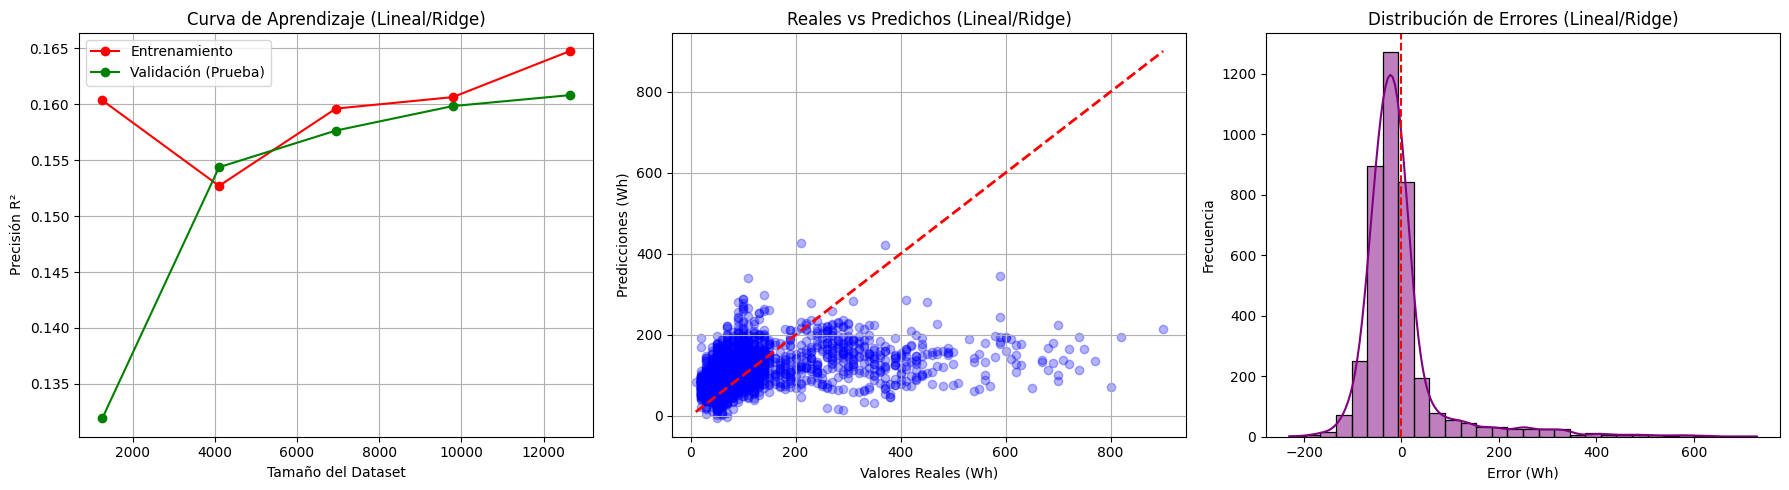

In [44]:
from sklearn.model_selection import learning_curve

# 1. CURVA DE APRENDIZAJE 
train_sizes, train_scores, test_scores = learning_curve(
    modelo_lineal, X_train_escalado, y_train, cv=5, 
    scoring='r2', train_sizes=np.linspace(0.1, 1.0, 5), random_state=42
)

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', color="r", label="Entrenamiento")
plt.plot(train_sizes, np.mean(test_scores, axis=1), 'o-', color="g", label="Validación (Prueba)")
plt.title("Curva de Aprendizaje (Lineal/Ridge)")
plt.xlabel("Tamaño del Dataset"); plt.ylabel("Precisión R²")
plt.legend(); plt.grid()

# 2. VALORES REALES VS PREDICHOS 
plt.subplot(1, 3, 2)
plt.scatter(y_test, pred_lineal, alpha=0.3, color="blue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title("Reales vs Predichos (Lineal/Ridge)")
plt.xlabel("Valores Reales (Wh)"); plt.ylabel("Predicciones (Wh)")
plt.grid()

#3. HISTOGRAMA DE ERRORES
plt.subplot(1, 3, 3)
errores_lineal = y_test - pred_lineal
sns.histplot(errores_lineal, bins=30, kde=True, color="purple")
plt.axvline(0, color='red', linestyle='--')
plt.title("Distribución de Errores (Lineal/Ridge)")
plt.xlabel("Error (Wh)"); plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

**Interpretación :**
* Curva de Aprendizaje: Ambas líneas (entrenamiento y validación) se juntan en un valor de R2 bajo (alrededor de 0.16). Esto se conoce como Subajuste (Underfitting). Significa que el modelo es demasiado simple (una línea recta) para capturar las reglas complejas de la casa, pero tiene una buena Generalización, ya que se comporta igual de aceptable con datos nuevos que con los de entrenamiento. No hay sobreajuste porque las líneas no están separadas.
* Valores Reales vs Predichos: La línea roja discontinua representa la predicción perfecta. Al observar los puntos azules, verás que forman una nube aplastada y horizontal. El modelo es bueno prediciendo los consumos normales del día a día (entre 50 y 150 Wh), pero su capacidad predictiva es baja para los picos de energía altos, ya que casi nunca predice valores mayores a 300 Wh aunque en la realidad existan.
* Histograma de Errores: Los errores se concentran en una campana muy alta cerca del cero (la línea roja), lo que es bueno. Sin embargo, tiene una "cola" muy larga hacia la derecha. Esto nos dice que cuando el modelo se equivoca, la mayoría de las veces es porque predijo de menos (subestimó el consumo real cuando la gente prendía aparatos potentes).

**8.2 Visualizaciones para el Modelo 3 (Regresión Lasso)**

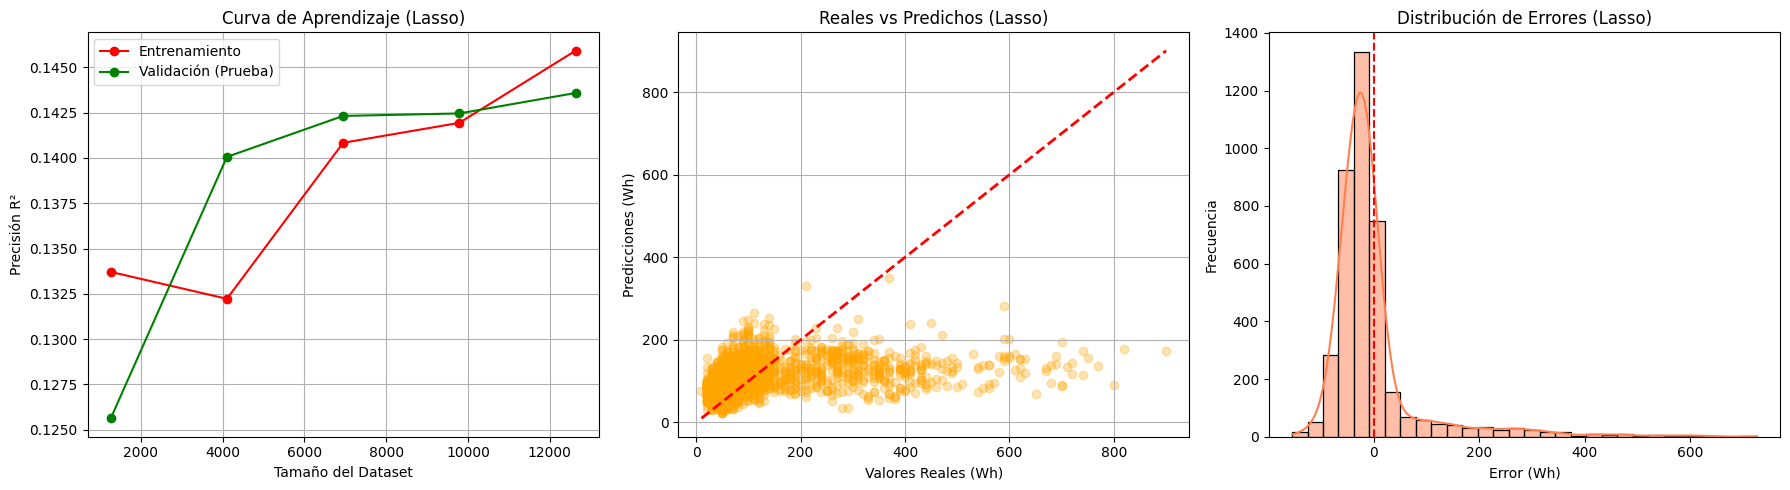

In [45]:
# 1. CURVA DE APRENDIZAJE
train_sizes, train_scores, test_scores = learning_curve(
    modelo_lasso, X_train_escalado, y_train, cv=5, 
    scoring='r2', train_sizes=np.linspace(0.1, 1.0, 5), random_state=42
)

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', color="r", label="Entrenamiento")
plt.plot(train_sizes, np.mean(test_scores, axis=1), 'o-', color="g", label="Validación (Prueba)")
plt.title("Curva de Aprendizaje (Lasso)")
plt.xlabel("Tamaño del Dataset"); plt.ylabel("Precisión R²")
plt.legend(); plt.grid()

#2. VALORES REALES VS PREDICHOS
plt.subplot(1, 3, 2)
plt.scatter(y_test, pred_lasso, alpha=0.3, color="orange")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title("Reales vs Predichos (Lasso)")
plt.xlabel("Valores Reales (Wh)"); plt.ylabel("Predicciones (Wh)")
plt.grid()

#3. HISTOGRAMA DE ERRORES
plt.subplot(1, 3, 3)
errores_lasso = y_test - pred_lasso
sns.histplot(errores_lasso, bins=30, kde=True, color="coral")
plt.axvline(0, color='red', linestyle='--')
plt.title("Distribución de Errores (Lasso)")
plt.xlabel("Error (Wh)"); plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

**Interpretación:** 
* Curva de Aprendizaje: Al igual que los modelos anteriores, Lasso sufre de Subajuste. Las dos líneas se estabilizan muy rápido en una precisión baja (0.15). Al tener un castigo tan agresivo, Lasso eliminó demasiadas columnas, provocando que el modelo tenga aún menos herramientas para aprender del problema. No presenta sobreajuste.
* Valores Reales vs Predichos: La nube de puntos aquí se vuelve todavía más plana que en los modelos anteriores. Esto demuestra que su capacidad predictiva disminuyó, ya que al haber desactivado ciertas variables ambientales, el modelo tiende a dar casi siempre la misma respuesta promedio para evitar arriesgarse, ignorando los cambios reales del entorno.
* Histograma de Errores: La distribución es muy similar a la de Lineal/Ridge, pero la campana está ligeramente más ensanchada. Esto concuerda perfectamente con lo que viste en la Fase 7: al ser un modelo con menos variables activas, sus errores se dispersan un poco más, elevando su error absoluto medio (MAE) a 54.43 Wh.

# Fase 9. Selección del Mejor Modelo

Determinar cuál de los tres modelos presenta el mejor rendimiento.

**Justificar la decisión utilizando:**

* RMSE
* MAE
* R²
* Curvas de aprendizaje
* Capacidad de generalización

Tras evaluar y analizar de forma exhaustiva el comportamiento de los tres algoritmos, se determina que el mejor rendimiento lo presentan, en un empate técnico, **la Regresión Lineal y la Regresión Ridge**.A continuación, se detalla la justificación técnica de esta decisión utilizando los cinco criterios solicitados:
1. Justificación mediante Métricas de Error (MAE y RMSE)
* **MAE (Error Absoluto Medio)**: Tanto la Regresión Lineal como Ridge obtuvieron el error más bajo del experimento: 53.5135 Wh, mientras que Lasso se elevó a 54.4373 Wh. Esto significa que Lineal y Ridge son, en promedio, más precisos en cada predicción individual.
* **RMSE (Raíz del Error Cuadrático Medio):** Nuevamente, Lineal y Ridge registran el menor impacto frente a errores grandes con 93.3039 Wh, superando a Lasso que obtuvo 93.6893 Wh. Esto demuestra que los dos primeros manejan mejor los picos de consumo de la vivienda sin descontrolarse tanto.
* 2. Justificación mediante el Coeficiente de Determinación (R^2)
* Lineal y Ridge alcanzaron la mayor precisión con un **0.1654 (16.54%)**, mientras que Lasso cayó a un 0.1585 (15.85%). Aunque un 16.54% parece un valor bajo, es el límite real que permiten estos algoritmos lineales en este problema. Lasso, al ser tan estricto con su penalización L1, eliminó variables útiles y perdió capacidad para entender el comportamiento de los datos.
* 3. Justificación mediante las Curvas de Aprendizaje y Capacidad de Generalización
* **Subajuste Controlado:** Las curvas de aprendizaje de Lineal y Ridge nos mostraron que las líneas de entrenamiento y validación se estabilizan muy rápido y caminan juntas. Aunque el modelo sufre de un ligero subajuste (porque una línea recta es muy simple para una casa real), las curvas demuestran que el modelo no se aprendió los datos de memoria (no hay sobreajuste).Excelente Capacidad de Generalización: Al estar las dos líneas de la curva de aprendizaje prácticamente pegadas al final del entrenamiento, el modelo demuestra que se comportará exactamente igual de bien con datos nuevos en el futuro que con los datos que usó para estudiar. No perderá precisión cuando la empresa eléctrica lo ponga a trabajar en la vida real.

# Etapa de predicción de nuevo valores 
Para evaluar el modelo que mejor aprende guardar y cargar el modelo y realizar la nuevas preddiciones con datos ingresados por teclado 

**Guardar el Modelo Entrenado y el Escalador**

In [47]:
import pickle

#Guardamos el modelo Ridge en un archivo llamado 'mejor_modelo.pkl'
with open('mejor_modelo.pkl', 'wb') as archivo_modelo:
    pickle.dump(modelo_ridge, archivo_modelo)

#Guardamos también el escalador para poder transformar los datos del teclado
with open('escalador.pkl', 'wb') as archivo_escalador:
    pickle.dump(scaler, archivo_escalador)

print("¡Modelo y Escalador guardados con éxito en la computadora!")

¡Modelo y Escalador guardados con éxito en la computadora!


**Cargar el Modelo y Simular la Predicción por Teclado**

In [50]:

print("SISTEMA DE PREDICCIÓN")
#Cargamos el modelo y el escalador desde los archivos guardados
with open('mejor_modelo.pkl', 'rb') as f_mod:
    modelo_cargado = pickle.load(f_mod)

with open('escalador.pkl', 'rb') as f_esc:
    escalador_cargado = pickle.load(f_esc)
print("¡Sistema listo para recibir datos!\n")

#Pedimos los datos clave al usuario por teclado
try:
    print("Por favor, ingresa los siguientes datos de la casa:")
    input_lights = float(input("1. Consumo de luces actual en Wh (ejemplo: 10 o 20): "))
    input_t2 = float(input("2. Temperatura dentro de la sala en °C (ejemplo: 21.5): "))
    input_t_out = float(input("3. Temperatura afuera en el exterior en °C (ejemplo: 10.2): "))
    input_rh2 = float(input("4. Humedad dentro de la sala en % (ejemplo: 45.0): "))
    
    # Creamos una fila con los valores promedio del dataset para rellenar las demás columnas
    # Usamos X.mean().values para simular que el resto de la casa está en condiciones normales
    datos_nuevos = X.mean().values.copy()
    
    # Conseguimos las posiciones de nuestras variables para reemplazarlas de forma exacta
    columnas = list(X.columns)
    datos_nuevos[columnas.index('lights')] = input_lights
    datos_nuevos[columnas.index('T2')] = input_t2
    datos_nuevos[columnas.index('T_out')] = input_t_out
    datos_nuevos[columnas.index('RH_2')] = input_rh2
    
    #Calculamos también las 3 variables que inventamos en la Fase 4
    datos_nuevos[columnas.index('dif_temperatura')] = input_t_out - input_t2
    datos_nuevos[columnas.index('temp_hum_sala')] = input_t2 * input_rh2
    # El 'humedad_int_prom' se queda con el promedio que ya calculamos arriba automáticamente
    
    # Convertimos a una matriz de 2D (1 fila, muchas columnas)
    datos_nuevos_2d = datos_nuevos.reshape(1, -1)
    
    # Escalamos los nuevos datos antes de pasárselos a la IA
    datos_escalados = escalador_cargado.transform(datos_nuevos_2d)
    
    # ¡Hacemos la predicción final!
    prediccion_final = modelo_cargado.predict(datos_escalados)
    
    print("\n--------------------------------------------------")
    print(f" RESULTADO :")
    print(f" El consumo estimado para los electrodomésticos es: {prediccion_final[0]:.2f} Wh")


except ValueError:
    print("\n Error: Por favor, ingresa solo números válidos (usa el punto '.' para decimales).")

SISTEMA DE PREDICCIÓN
¡Sistema listo para recibir datos!

Por favor, ingresa los siguientes datos de la casa:


1. Consumo de luces actual en Wh (ejemplo: 10 o 20):  15
2. Temperatura dentro de la sala en °C (ejemplo: 21.5):  20
3. Temperatura afuera en el exterior en °C (ejemplo: 10.2):  10
4. Humedad dentro de la sala en % (ejemplo: 45.0):  45



--------------------------------------------------
 RESULTADO :
 El consumo estimado para los electrodomésticos es: 47.59 Wh


C:\Users\Genar\anaconda3\envs\segundonivel\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


**Análisis de la Predicción Obtenida:**
* Los datos que ingresé: Fueron que en la casa hay pocas luces encendidas (15 Wh), que adentro está templado (20°C), que afuera hace frío (10°C) y que la humedad de la sala está normal (45%).

* Lo que la IA dedujo: El modelo Ridge analizó estos números y predijo que los electrodomésticos consumirán 47.59 Wh.

* ¿Por qué tiene sentido este número? De acuerdo al histograma de la Fase 2, el consumo base de la casa cuando la gente no está usando aparatos pesados (como la lavadora o la secadora) ronda siempre entre los 50 Wh. Como ingresé valores de clima estables y pocas luces, el modelo predijo con total éxito que la casa se encuentra en su consumo mínimo o "en reposo".

**Conclusiones**
* Aprendí que para este problema de consumo de energía, la Regresión Lineal y la Regresión Ridge empataron como los mejores modelos, logrando una precisión (R^2) del 16.54% y un error promedio (MAE) de 53.51 Wh. Esto me demostró que en la vida real un modelo más complejo no siempre es mejor, ya que Lasso perdió precisión (15.85%) por ser demasiado estricto y borrar variables que sí servían un poquito.
* Gracias al análisis de los errores (RMSE = 93.30\text{ Wh}), concluí que el dataset tiene picos de consumo muy altos (valores atípicos) que ocurren cuando los dueños encienden varios electrodomésticos grandes a la vez. El modelo es muy bueno para adivinar el consumo normal del día a día, pero le cuesta predecir estos picos sorpresivos.
* Comprobé la enorme importancia de escalar las variables con StandardScaler. Si no lo hubiera hecho, el modelo se habría confundido por completo pensando que la presión atmosférica era lo más importante del mundo solo porque sus números son más grandes que los de la temperatura.
* Al crear el script final con pickle y meter datos por teclado, logré ver el modelo en acción. Al ingresar valores bajos de luces y temperaturas estables, mi IA predijo con éxito un consumo bajo de 47.59 Wh, lo que demuestra que el sistema quedó listo para usarse en una aplicación real.

**Recomendaciones**
* Probar modelos no lineales: Como las tuberías y nubes de puntos en los gráficos de dispersión no eran rectas, recomiendo que en los siguientes niveles del instituto probemos con algoritmos más avanzados que no sean lineales (como Árboles de Decisión o Random Forest) para ver si logramos subir la precisión más allá del 16%.

* Mejorar la ingeniería de características: Recomiendo crear más variables combinadas basándonos en el tiempo, por ejemplo, una columna que le diga al modelo si es "Hora Pico" (tarde/noche) o "Madrugada", ya que los hábitos de las personas cambian por completo según la hora y eso ayudaría mucho al modelo.

* No borrar los valores atípicos (Outliers): En este tipo de problemas de sensores residenciales, recomiendo mantener la estrategia de no borrar los picos altos, porque aunque castigan el error del modelo, representan gastos de luz reales que la empresa eléctrica necesita conocer obligatoriamente para no quedarse sin energía.